# ML1 (2026) Task2: Developer Salary Prediction (regression)

Predict annual compensation of software developers from the Developer Survey

## Overview

This notebook covers the full modeling pipeline for Task 2. We compared all regression methods from the ML1 syllabus: OLS, Ridge, LASSO, Elastic Net, KNN, and SVR with an RBF kernel. The final model is a linear ensemble of SVR-RBF and Elastic Net, with weights learned on a held-out validation set.

Key decisions that shaped the approach:

- **R17 data quality.** R17 contains around 44% of observations with a salary range from $1 to over $4M within a single region. We concluded that some respondents reported in local currency rather than USD, so we removed R17 rows below $500 from the training set only, leaving validation and test untouched.
- **Log transformation.** We modeled log1p(salary) as the target to reduce skewness and applied Duan's smearing correction when back-transforming predictions to the dollar scale.
- **SVR grid.** The initial SVR grid (C up to 0.5) was too conservative and caused the model to underfit high earners. We widened it substantially.
- **Feature engineering.** We focused on experience-related terms (quadratic and log), seniority keywords extracted from dev.role, technology breadth counts across multi-select columns, and missingness indicators for AI-related columns that are only shown to AI tool users.

## Methods used

OLS, Ridge, LASSO, Elastic Net, KNN, SVR (RBF kernel).

In [1]:
import warnings
warnings.filterwarnings("ignore")

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_val_predict
from sklearn.preprocessing import StandardScaler, OneHotEncoder, RobustScaler, TargetEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, RidgeCV, Lasso, LassoCV, ElasticNet, ElasticNetCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
from sklearn.base import clone

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 110, "figure.facecolor": "white"})

SEED = 42
TARGET = "annual.pay.usd"
ID_COL = "id"
MULTI_SEP = ";"

## Data loading

In [2]:
df_raw = pd.read_csv("train.csv")
kaggle_raw = pd.read_csv("test.csv")

print(f"train: {df_raw.shape}, test: {kaggle_raw.shape}")
print(f"target - min=${df_raw[TARGET].min():,.0f}, median=${df_raw[TARGET].median():,.0f}, mean=${df_raw[TARGET].mean():,.0f}, max=${df_raw[TARGET].max():,.0f}")
print(f"raw skewness: {df_raw[TARGET].skew():.2f}, log skewness: {np.log(df_raw[TARGET].clip(lower=1)).skew():.2f}")


train: (2512, 41), test: (628, 41)
target - min=$1, median=$40,828, mean=$49,713, max=$4,773,360
raw skewness: 33.13, log skewness: -1.66


In [3]:
NUMERIC_COLS = ["coding.years.total", "coding.years.professional", "experience.years", "job.satisfaction"]
ORDINAL_COLS = ["age.group", "education", "company.size", "tech.purchase.influence", "ai.sentiment", "ai.trust", "ai.complex.rating", "daily.search.time", "daily.answer.time"]
NOMINAL_COLS = ["region", "employment.type", "work.location", "is.dev.professional", "dev.role", "people.manager", "industry", "build.vs.buy", "cloud.hosting", "first.help.source", "uses.ai", "ai.job.threat"]
MULTI_SELECT_COLS = ["side.coding", "how.learned.coding", "prog.languages", "databases", "cloud.platforms", "web.frameworks", "other.tech", "dev.tools", "dev.environments", "personal.os", "work.os", "project.mgmt.tools", "comm.tools", "ai.search.tools", "ai.tools.used"]

all_defined = [TARGET] + NUMERIC_COLS + ORDINAL_COLS + NOMINAL_COLS + MULTI_SELECT_COLS
unlisted = [c for c in df_raw.columns if c not in all_defined]
missing_from_df = [c for c in all_defined if c not in df_raw.columns]

print(f"total columns in dataframe: {df_raw.shape[1]}")
print(f"total columns in our lists: {len(all_defined)}")
print(f"unlisted (in df, not in lists): {unlisted if unlisted else 'none'}")
print(f"missing (in lists, not in df):  {missing_from_df if missing_from_df else 'none'}")

total columns in dataframe: 41
total columns in our lists: 41
unlisted (in df, not in lists): none
missing (in lists, not in df):  none


In [4]:
print()
for col in df_raw.columns:
    if col == TARGET:
        tag = "TARGET"
    elif col in NUMERIC_COLS:
        tag = "numeric"
    elif col in ORDINAL_COLS:
        tag = "ordinal"
    elif col in NOMINAL_COLS:
        tag = "nominal"
    elif col in MULTI_SELECT_COLS:
        tag = "multi-select"
    else:
        tag = "UNLISTED"
    print(f"  {col:<35} {tag}")


  annual.pay.usd                      TARGET
  region                              nominal
  age.group                           ordinal
  employment.type                     nominal
  work.location                       nominal
  education                           ordinal
  is.dev.professional                 nominal
  coding.years.total                  numeric
  coding.years.professional           numeric
  experience.years                    numeric
  dev.role                            nominal
  company.size                        ordinal
  people.manager                      nominal
  industry                            nominal
  tech.purchase.influence             ordinal
  build.vs.buy                        nominal
  side.coding                         multi-select
  how.learned.coding                  multi-select
  prog.languages                      multi-select
  databases                           multi-select
  cloud.platforms                     multi-select
  web.fra

## Exploratory Data Analysis

### Target distribution

The raw target is extremely right-skewed (skewness over 33), so we model log1p(salary).

raw skewness: 33.13
log skewness: -1.64


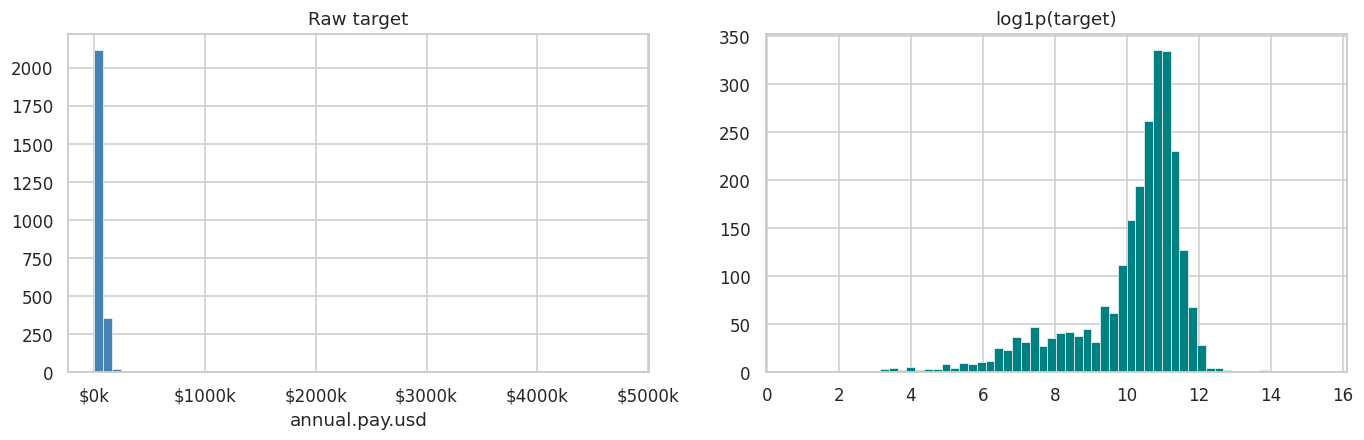

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

axes[0].hist(df_raw[TARGET], bins=60, color="steelblue", edgecolor="white", lw=0.4)
axes[0].set_title("Raw target")
axes[0].set_xlabel("annual.pay.usd")
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e3:.0f}k"))

axes[1].hist(np.log1p(df_raw[TARGET]), bins=60, color="teal", edgecolor="white", lw=0.4)
axes[1].set_title("log1p(target)")

print(f"raw skewness: {df_raw[TARGET].skew():.2f}")
print(f"log skewness: {np.log1p(df_raw[TARGET]).skew():.2f}")

### Missing values

32 out of 41 columns have at least some missing data. Columns above 30% missing are highlighted - most of them are AI-related, which turns out to be meaningful.

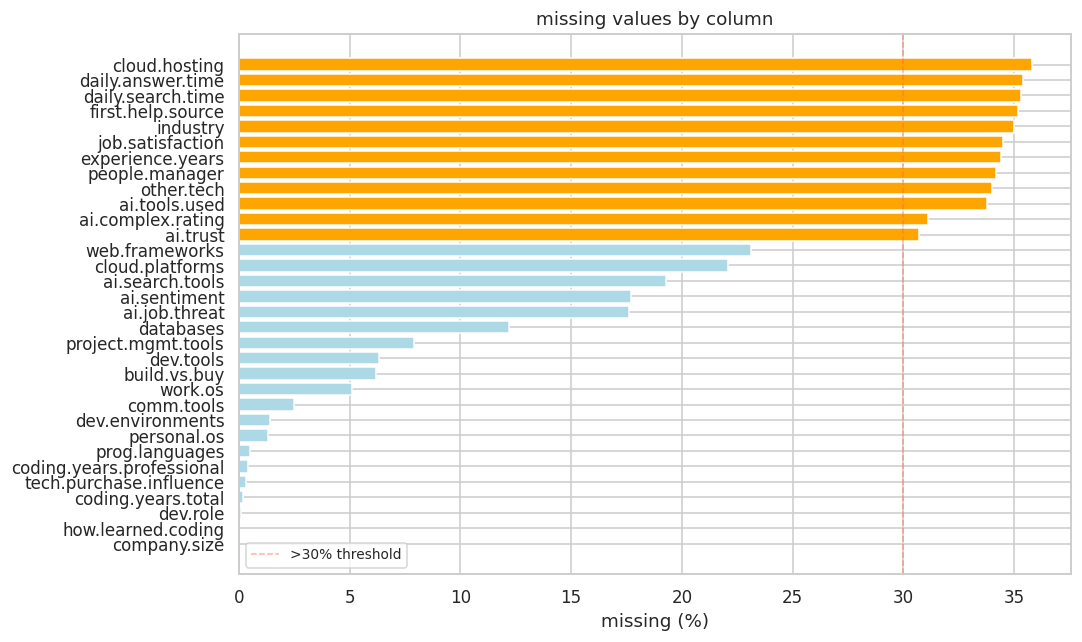

columns with >30% missing: 12
columns with 10-30% missing: 6
columns with >0% but <10%: 14
columns with no missing: 9
total: 41


In [6]:
miss = df_raw.isnull().sum()
miss_pct = (miss / len(df_raw) * 100).round(1)
miss_df = pd.DataFrame({"n": miss, "pct": miss_pct})
miss_df = miss_df[miss_df["n"] > 0].sort_values("pct", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["orange" if p > 30 else "lightblue" for p in miss_df["pct"]]
ax.barh(miss_df.index, miss_df["pct"], color=colors, edgecolor="white")
ax.axvline(30, color="tomato", linestyle="--", linewidth=1, alpha=0.5, label=">30% threshold")
ax.set_xlabel("missing (%)")
ax.set_title("missing values by column")
ax.invert_yaxis()
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"columns with >30% missing: {(miss_df['pct'] > 30).sum()}")
print(f"columns with 10-30% missing: {((miss_df['pct'] > 10) & (miss_df['pct'] <= 30)).sum()}")
print(f"columns with >0% but <10%: {(miss_df['pct'] <= 10).sum()}")
print(f"columns with no missing: {(df_raw.isnull().sum() == 0).sum()}")
print(f"total: {df_raw.shape[1]}")

### AI column missingness pattern
The AI columns are only shown to respondents who answered "Yes" to `uses.ai`. Rows where these columns are missing consistently earn more than rows where they are present, meaning missingness carries a salary signal. Simple imputation would throw this away, so we add binary missingness flags instead.

In [7]:
ai_miss_cols = ["ai.trust", "ai.complex.rating", "ai.tools.used", "ai.search.tools", "ai.sentiment"]

print(f"{'column':<24} {'present median':>15} {'missing median':>15} {'diff':>8}")
print("-" * 66)
for col in ai_miss_cols:
    m_present = df_raw.loc[df_raw[col].notna(), TARGET].median()
    m_missing = df_raw.loc[df_raw[col].isna(), TARGET].median()
    diff = (m_missing - m_present) / m_present * 100
    print(f"{col:<24} ${m_present:>14,.0f} ${m_missing:>14,.0f} {diff:>+7.1f}%")

column                    present median  missing median     diff
------------------------------------------------------------------
ai.trust                 $        39,241 $        44,562   +13.6%
ai.complex.rating        $        39,282 $        44,405   +13.0%
ai.tools.used            $        39,470 $        43,905   +11.2%
ai.search.tools          $        40,134 $        43,980    +9.6%
ai.sentiment             $        39,744 $        45,201   +13.7%


### Correlations with log target

Spearman correlations of numeric features with log(salary). The three experience columns dominate, which motivates most of the feature engineering in the next section.

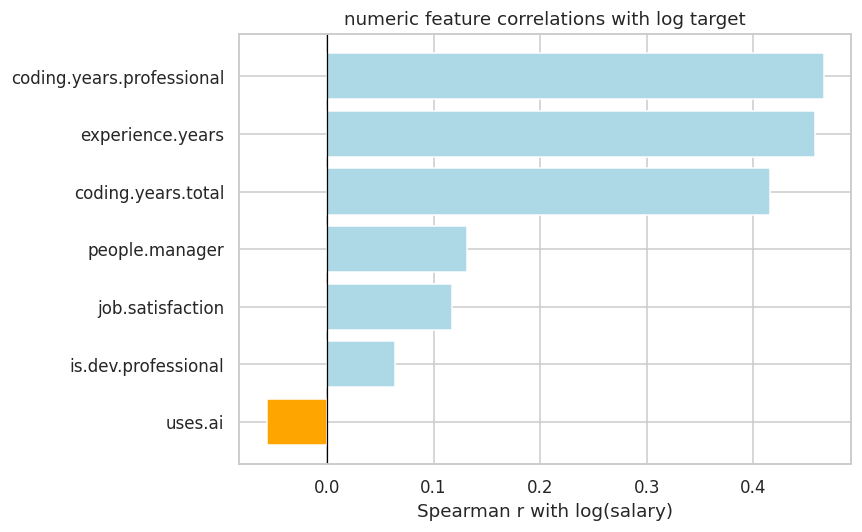

In [8]:
log_target = np.log1p(df_raw[TARGET])

corr_records = []

for col in ["coding.years.total", "coding.years.professional", "experience.years", "job.satisfaction"]:
    r = df_raw[col].corr(log_target, method="spearman")
    corr_records.append({"feature": col, "r": r})

for col, mapping in [
    ("people.manager", {"People manager": 1, "Individual contributor": 0}),
    ("is.dev.professional", {
        "I am a developer by profession": 1,
        "I am not primarily a developer, but I write code sometimes as part of my work/studies": 0
    }),
    ("uses.ai", {"Yes": 1, "No, but I plan to soon": 0.5, "No, and I don't plan to": 0}),
]:
    enc = df_raw[col].map(mapping)
    r = enc.corr(log_target, method="spearman")
    corr_records.append({"feature": col, "r": r})

corr_df = pd.DataFrame(corr_records).sort_values("r", key=abs, ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["orange" if r < 0 else "lightblue" for r in corr_df["r"]]
ax.barh(corr_df["feature"], corr_df["r"], color=colors, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Spearman r with log(salary)")
ax.set_title("numeric feature correlations with log target")
plt.tight_layout()
plt.show()

### Multicollinearity in experience columns

All three experience columns are highly correlated with each other. Keeping all three would introduce redundancy, so we drop `coding.years.total` and replace it with `years.before.professional` (the difference), which captures pre-career coding time independently.

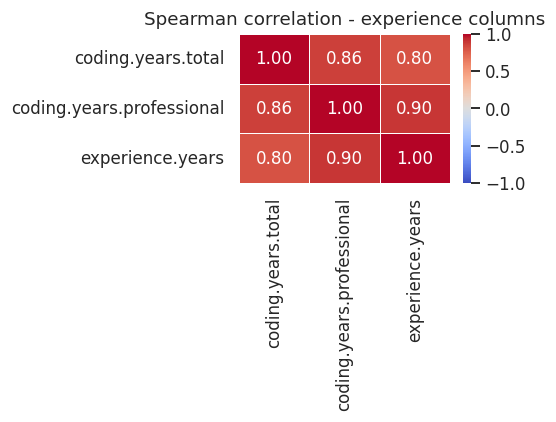

In [9]:
exp_cols = ["coding.years.total", "coding.years.professional", "experience.years"]
corr = df_raw[exp_cols].corr(method="spearman")

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, linewidths=0.5, ax=ax, annot_kws={"size": 11})
ax.set_title("Spearman correlation - experience columns")
plt.tight_layout()
plt.show()

### Region is the strongest predictor

Because region is nominal, Spearman correlation does not apply. We use the Kruskal-Wallis H statistic and eta-squared instead, which is the non-parametric equivalent of a one-way ANOVA effect size. The eta-squared value puts region well above any individual numeric feature.

region: H=267.1, p=6.48e-47, eta-squared=0.1003


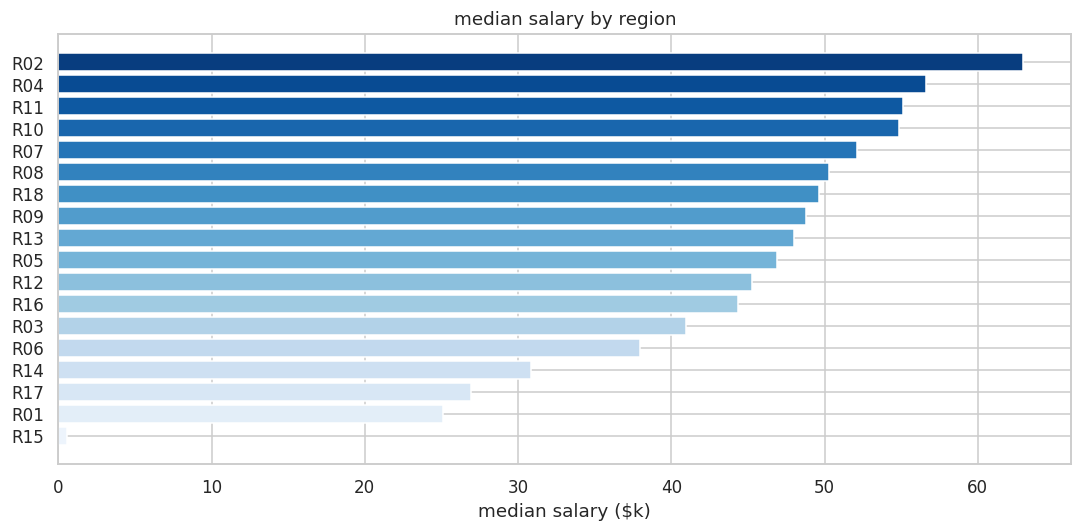

In [10]:
from scipy import stats

n = df_raw[TARGET].notna().sum()
groups = [df_raw.loc[df_raw["region"] == r, TARGET].dropna().values
          for r in df_raw["region"].dropna().unique()]
groups = [g for g in groups if len(g) > 0]
H, p = stats.kruskal(*groups)
eta2 = max(0, (H - len(groups) + 1) / (n - len(groups)))
print(f"region: H={H:.1f}, p={p:.2e}, eta-squared={eta2:.4f}")

region_med = df_raw.groupby("region")[TARGET].median().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(region_med.index, region_med.values / 1e3,
        color=sns.color_palette("Blues_r", n_colors=len(region_med)), edgecolor="white")
ax.set_xlabel("median salary ($k)")
ax.set_title("median salary by region")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Target distribution and R17 anomaly

The raw target is extremely right-skewed (skewness over 33), so we model log1p(salary). The third panel already shows R17 is much wider than all other regions on the log scale. The table below makes this concrete: R17's standard deviation is roughly 3x higher than the rest of the dataset combined, and it simultaneously contains the lowest salaries (down to $1) and some of the highest (up to $4.77M). A single region having both extremes is hard to explain by anything other than for example respondents reporting in different currencies, which is why we treat these low values as noise rather than genuine salary data.

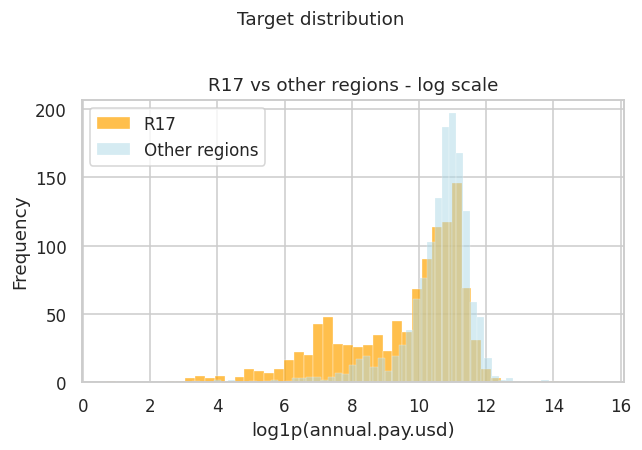

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

r17_log = np.log1p(df_raw.loc[df_raw["region"] == "R17", TARGET])
other_log = np.log1p(df_raw.loc[df_raw["region"] != "R17", TARGET])

ax.hist(
    r17_log,
    bins=50,
    alpha=0.7,
    color="orange",
    edgecolor="white",
    lw=0.3,
    label="R17"
)

ax.hist(
    other_log,
    bins=50,
    alpha=0.5,
    color="lightblue",
    edgecolor="white",
    lw=0.3,
    label="Other regions"
)

ax.set_title("R17 vs other regions - log scale")
ax.set_xlabel(f"log1p({TARGET})")
ax.set_ylabel("Frequency")
ax.legend()

plt.suptitle("Target distribution", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()



In [12]:
r17 = df_raw.loc[df_raw["region"] == "R17", TARGET]
other = df_raw.loc[df_raw["region"] != "R17", TARGET]

print(f"\nR17 ({len(r17)} obs) vs other regions ({len(other)} obs):")
print(f" {'':20} {'R17':>12} {'other':>12}")
print(f" {'min':20} {r17.min():>12,.0f} {other.min():>12,.0f}")
print(f" {'P1':20} {r17.quantile(0.01):>12,.0f} {other.quantile(0.01):>12,.0f}")
print(f" {'median':20} {r17.median():>12,.0f} {other.median():>12,.0f}")
print(f" {'P99':20} {r17.quantile(0.99):>12,.0f} {other.quantile(0.99):>12,.0f}")
print(f" {'max':20} {r17.max():>12,.0f} {other.max():>12,.0f}")
print(f" {'std':20} {r17.std():>12,.0f} {other.std():>12,.0f}")
print(f"\nR17 rows with salary < $500: {((df_raw['region'] == 'R17') & (df_raw[TARGET] < 500)).sum()}")
print(f"R17 rows with salary < $1,000: {((df_raw['region'] == 'R17') & (df_raw[TARGET] < 1000)).sum()}")
print(f"R17 rows with salary > $200,000: {((df_raw['region'] == 'R17') & (df_raw[TARGET] > 200_000)).sum()}")


R17 (1108 obs) vs other regions (1404 obs):
                               R17        other
 min                             1           25
 P1                             39          651
 median                     26,930       49,724
 P99                       160,983      189,500
 max                     4,773,360    1,042,782
 std                       153,110       53,884

R17 rows with salary < $500: 71
R17 rows with salary < $1,000: 130
R17 rows with salary > $200,000: 6


## Train / validation / test split

We split the data into 70% training, 15% validation, and 15% test data. Because R17 seems to behave differently from other regions, we stratify the split using R17 membership. This means that each dataset keeps approximately the same share of R17 and non-R17 observations. Thanks to this, the validation and test sets are more comparable to the training set, and our model evaluation is less affected by accidental differences in regional composition.

In [13]:
df_raw = df_raw.copy()
df_raw["_r17_strat"] = np.where(df_raw["region"] == "R17", "R17", "Other")

train_df, temp_df = train_test_split(
    df_raw, test_size=0.30, random_state=SEED,
    stratify=df_raw["_r17_strat"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=SEED,
    stratify=temp_df["_r17_strat"]
)

for d in (train_df, val_df, test_df, df_raw):
    d.drop(columns=["_r17_strat"], inplace=True, errors="ignore")

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"split: train={len(train_df)}, val={len(val_df)}, test={len(test_df)}")

split: train=1758, val=377, test=377


### R17 cleaning

We drop R17 rows with salary below $500 from training only. These are almost certainly local-currency reports because no major developer market has a median annual salary anywhere near $500 USD.

**No upper-tail winsorisation.** An earlier version capped salaries at the per-region 99th percentile to remove suspected high-salary outliers. That cleaning *lowered* the internal test RMSE on the cleaned distribution but *worsened* the Kaggle leaderboard score, because removing the right tail from training also removed the signal the model needs to predict legitimate high earners on the real test set. In v7 we keep all observations above $500 intact.


In [14]:
MIN_SALARY_FLOOR = 500.0


def clean_training_targets(df):
    """Drop implausibly low R17 rows (salary likely reported in local currency).

    NOTE: No upper-tail winsorisation. Capping high earners (per-region P99 or
    similar) was tried in an earlier version and degraded leaderboard
    performance: the right tail of the real test distribution carries genuine
    high-salary signal that the model needs to see during training.
    """
    df = df.copy()
    mask_low = (df["region"] == "R17") & (df[TARGET] < MIN_SALARY_FLOOR)
    df = df.loc[~mask_low].reset_index(drop=True)
    return df


n_before = len(train_df)
train_df = clean_training_targets(train_df)

print(f"training rows: {n_before} -> {len(train_df)}")
print(f"training target max after cleaning: ${train_df[TARGET].max():,.0f}  (kept intact)")


training rows: 1758 -> 1709
training target max after cleaning: $4,773,360  (kept intact)


### Log-transforming the target

We model log1p(salary). The few val/test rows with salary below $500 are floored before the log to avoid log(0).

In [15]:
def make_log_target(df):
    return np.log1p(df[TARGET].clip(lower=MIN_SALARY_FLOOR))

y_train = make_log_target(train_df).values
y_val = make_log_target(val_df).values
y_test = make_log_target(test_df).values

print(f"y_train - min: {y_train.min():.2f}, max: {y_train.max():.2f}, mean: {y_train.mean():.2f}, std: {y_train.std():.2f}")
print(f"skewness after log transform: {pd.Series(y_train).skew():.3f}")

y_train - min: 6.22, max: 15.38, mean: 10.26, std: 1.31
skewness after log transform: -1.203


## Feature engineering

We created several groups of features:

- **Experience variables.** We dropped `coding.years.total` (Spearman r=0.86 with `coding.years.professional`) and replaced it with `years.before.professional` (the difference). We also added quadratic and log terms for the two retained experience columns to capture the likely diminishing-returns shape.
- **Seniority flags.** We extracted binary flags from dev.role strings for keywords like Senior, Lead, Manager, Junior, Principal, etc.
- **Technology breadth.** For each multi-select column we created a count feature and binary indicators for the top 25 most common items. The top-N lists are identified from the training set only to avoid leakage. We also added a global `tech_breadth_total` that sums the per-column counts; this is a linear combination of the count features (so it is informationally redundant for OLS/Ridge/LASSO/EN) but acts as a single useful aggregate input for the SVR-RBF model, which is non-linear and can exploit it.
- **Missingness indicators.** The AI-related columns (ai.trust, ai.complex.rating, ai.tools.used, etc.) are only shown to respondents who use AI tools. Missing rows in these columns actually earn more, so missingness is informative here. We added a binary flag for each column with over 10% missing.
- **Region x company size interaction.** A string concatenation used as a new categorical feature for target encoding.
- **Ordinal mappings.** We used interval midpoints (e.g. age group "25-34" maps to 29.5) rather than simple integer ranks for better signal in distance-based and linear models.


In [16]:
unique_summary = pd.DataFrame({
    "column": df_raw.columns,
    "dtype": [df_raw[col].dtype for col in df_raw.columns],
    "n_unique_including_na": [df_raw[col].nunique(dropna=False) for col in df_raw.columns],
    "unique_values": [
        df_raw[col].drop_duplicates().head(30).to_list()
        for col in df_raw.columns
    ]
})

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)

unique_summary

,column,dtype,n_unique_including_na,unique_values
0,annual.pay.usd,float64,2437,"[44529.0, 82086.0, 14223.0, 78010.0, 38539.0, 66466.0, 12184.0, 48194.0, 42296.0, 132640.0, 324.0, 72913.0, 146168.0, 38855.0, 7194.0, 58680.0, 55616.0, 45703.0, 395342.0, 16352.0, 78906.0, 11808.0, 68370.0, 36025.0, 56429.0, 37693.0, 123806.0, 29940.0, 52794.0, 118016.0]"
1,region,str,18,"[R11, R05, R17, R18, R13, R04, R09, R06, R14, R03, R08, R02, R16, R12, R01, R10, R07, R15]"
2,age.group,str,5,"[35-44, 18-24, 25-34, 55+, 45-54]"
3,employment.type,str,5,"[Freelance/Self-employed, Full-time, Part-time, Student, Job-seeking]"
4,work.location,str,3,"[In-person, Remote, Hybrid (some remote, some in-person)]"
5,education,str,8,"[Master’s degree (M.A., M.S., M.Eng., MBA, etc.), Bachelor’s degree (B.A., B.S., B.Eng., etc.), Some college/university study without earning a degree, Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.), Professional degree (JD, MD, Ph.D, Ed.D, etc.), Associate degree (A.A., A.S., etc.), Primary/elementary school, Something else]"
6,is.dev.professional,str,2,"[I am a developer by profession, I am not primarily a developer, but I write code sometimes as part of my work/studies]"
7,coding.years.total,float64,47,"[29.0, 17.0, 4.0, 5.0, 6.0, 12.0, 2.0, 8.0, 14.0, 11.0, 20.0, 7.0, 16.0, 39.0, 19.0, 10.0, 21.0, 13.0, 18.0, 9.0, 40.0, 24.0, 33.0, 15.0, 25.0, 38.0, 3.0, 22.0, 35.0, 34.0]"
8,coding.years.professional,float64,40,"[16.0, 14.0, 0.0, 6.0, 4.0, 8.0, 3.0, 13.0, 11.0, 9.0, 12.0, 5.0, 10.0, 2.0, 23.0, 7.0, 15.0, 29.0, 34.0, 20.0, 31.0, 17.0, 1.0, 21.0, 26.0, 19.0, 32.0, 18.0, 39.0, 28.0]"
9,experience.years,float64,40,"[17.0, 13.0, 1.0, 5.0, 3.0, 8.0, 2.0, 7.0, 20.0, nan, 10.0, 11.0, 6.0, 4.0, 12.0, 15.0, 9.0, 21.0, 25.0, 0.0, 18.0, 23.0, 14.0, 19.0, 16.0, 28.0, 27.0, 22.0, 34.0, 38.0]"


### Ordinal maps and column lists
We manually encoded ordered categorical variables into numeric values, using midpoint-based values for age groups and rank-based values for ordinal survey answers. Binary variables such as professional developer status and people manager status were converted into 0/1 flags, while unknown company size was treated as missing. This made the variables usable for linear, regularized, SVR, and distance-based models while preserving their natural order.

In [17]:
# ordinal mappings - midpoint-based encoding
ORDINAL_MAPS = {
    "age.group": {"18-24": 21, "25-34": 29.5, "35-44": 39.5, "45-54": 49.5, "55+": 60},
    "education": {
        "Primary/elementary school": 0,
        "Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)": 1,
        "Some college/university study without earning a degree": 2,
        "Associate degree (A.A., A.S., etc.)": 3,
        "Something else": 3,
        "Bachelor\u2019s degree (B.A., B.S., B.Eng., etc.)": 4,
        "Master\u2019s degree (M.A., M.S., M.Eng., MBA, etc.)": 5,
        "Professional degree (JD, MD, Ph.D, Ed.D, etc.)": 6,
    },
    "company.size": {
        "Just me - I am a freelancer, sole proprietor, etc.": 0,
        "2 to 9 employees": 1,
        "10 to 19 employees": 2,
        "20 to 99 employees": 3,
        "100 to 499 employees": 4,
        "500 to 999 employees": 5,
        "1,000 to 4,999 employees": 6,
        "5,000 to 9,999 employees": 7,
        "10,000 or more employees": 8,
        "I don\u2019t know": np.nan,
    },
    "tech.purchase.influence": {
        "I have little or no influence": 0,
        "I have some influence": 1,
        "I have a great deal of influence": 2,
    },
    "ai.sentiment": {
        "Very unfavorable": 0, 
        "Unfavorable": 1, 
        "Indifferent": 2,
        "Unsure": 2, 
        "Favorable": 3, 
        "Very favorable": 4,
    },
    "ai.trust": {
        "Highly distrust": 0, 
        "Somewhat distrust": 1,
        "Neither trust nor distrust": 2, 
        "Somewhat trust": 3, 
        "Highly trust": 4,
    },
    "ai.complex.rating": {
        "Very poor at handling complex tasks": 0,
        "Bad at handling complex tasks": 1,
        "Neither good or bad at handling complex tasks": 2,
        "Good, but not great at handling complex tasks": 3,
        "Very well at handling complex tasks": 4,
    },
    "daily.search.time": {
        "Less than 15 minutes a day": 0, 
        "15-30 minutes a day": 1,
        "30-60 minutes a day": 2, 
        "60-120 minutes a day": 3,
        "Over 120 minutes a day": 4,
    },
    "daily.answer.time": {
        "Less than 15 minutes a day": 0, 
        "15-30 minutes a day": 1,
        "30-60 minutes a day": 2, 
        "60-120 minutes a day": 3,
        "Over 120 minutes a day": 4,
    },
    "is.dev.professional": {
        "I am a developer by profession": 1,
        "I am not primarily a developer, but I write code sometimes as part of my work/studies": 0,
    },
    "people.manager": {"People manager": 1, "Individual contributor": 0},
    "uses.ai": {"Yes": 2, "No, but I plan to soon": 1, "No, and I don't plan to": 0},
}


In [18]:
for val in df_raw["education"].dropna().unique():
    if "degree" in val.lower():
        print(repr(val))

'Master’s degree (M.A., M.S., M.Eng., MBA, etc.)'
'Bachelor’s degree (B.A., B.S., B.Eng., etc.)'
'Some college/university study without earning a degree'
'Professional degree (JD, MD, Ph.D, Ed.D, etc.)'
'Associate degree (A.A., A.S., etc.)'


In [19]:
for val in df_raw["company.size"].dropna().unique():
    if "know" in val.lower():
        print(repr(val))

'I don’t know'


In [20]:
for val in df_raw["uses.ai"].dropna().unique():
    print(repr(val))

'Yes'
"No, and I don't plan to"
'No, but I plan to soon'


In [21]:
print("checking ordinal maps against actual data values:")

for col, mp in ORDINAL_MAPS.items():
    if col not in df_raw.columns:
        continue

    actual = set(df_raw[col].dropna().unique())
    covered = set(mp.keys())
    unmapped = actual - covered

    original_na = df_raw[col].isna().sum()
    mapped_na = df_raw[col].map(mp).isna().sum()
    new_na = mapped_na - original_na

    status = f"UNMAPPED: {unmapped}" if unmapped else "ok"

    print(f"  {col:<25} {status}")

checking ordinal maps against actual data values:
  age.group                 ok
  education                 ok
  company.size              ok
  tech.purchase.influence   ok
  ai.sentiment              ok
  ai.trust                  ok
  ai.complex.rating         ok
  daily.search.time         ok
  daily.answer.time         ok
  is.dev.professional       ok
  people.manager            ok
  uses.ai                   ok


Below, `MULTI_SELECT_COLS` identifies columns where respondents could select multiple answers in one cell. These columns will later be transformed into a count feature, showing how many items were selected, and binary indicators for the 30 most common items in the training set.

`HIGH_MISS_COLS` is created automatically from the training data. We calculate the percentage of missing values in each column and select columns where more than 10% of values are missing. These columns receive additional missingness indicators, because missing values may contain useful information, especially for AI-related survey questions.

`ROLE_KEYWORDS` defines seniority-related words searched for inside the `dev.role` column. These keywords are later converted into binary flags, such as `role_is_senior`, `role_is_manager`, or `role_is_principal`, to capture seniority and leadership signals that may be related to salary.

All data-dependent selections, especially high-missing columns, are based only on the training set to avoid information leakage.

In [22]:
# columns that receive a missingness indicator (>10% missing in training)
MISS_THRESHOLD = 10.0

miss = train_df.isnull().sum()
miss_pct = (miss / len(train_df) * 100).round(1)

miss_df_train = pd.DataFrame({
    "n_missing": miss,
    "pct_missing": miss_pct
}).sort_values("pct_missing", ascending=False)

HIGH_MISS_COLS = (
    miss_df_train[
        (miss_df_train["pct_missing"] > MISS_THRESHOLD)
        & (miss_df_train["n_missing"] > 0)
    ]
    .index
    .tolist()
)

# seniority keywords extracted from dev.role strings
ROLE_KEYWORDS = ["Senior", "Junior", "Lead", "Manager", "Principal", "Staff", "Architect", "Director", "Executive", "VP"]


In [23]:
print("MULTI_SELECT_COLS")
print(f"Number of multi-select columns: {len(MULTI_SELECT_COLS)}")
print(MULTI_SELECT_COLS)

print(f"HIGH_MISS_COLS: columns with >{MISS_THRESHOLD}% missing in training set")
print(f"Number of high-missing columns: {len(HIGH_MISS_COLS)}")
print(HIGH_MISS_COLS)

print("\nDetailed missingness table for HIGH_MISS_COLS:")
display(miss_df_train.loc[HIGH_MISS_COLS])

print("ROLE_KEYWORDS")
print(f"Number of role keywords: {len(ROLE_KEYWORDS)}")
print(ROLE_KEYWORDS)

MULTI_SELECT_COLS
Number of multi-select columns: 15
['side.coding', 'how.learned.coding', 'prog.languages', 'databases', 'cloud.platforms', 'web.frameworks', 'other.tech', 'dev.tools', 'dev.environments', 'personal.os', 'work.os', 'project.mgmt.tools', 'comm.tools', 'ai.search.tools', 'ai.tools.used']
HIGH_MISS_COLS: columns with >10.0% missing in training set
Number of high-missing columns: 18
['cloud.hosting', 'daily.search.time', 'daily.answer.time', 'first.help.source', 'industry', 'ai.tools.used', 'job.satisfaction', 'experience.years', 'people.manager', 'other.tech', 'ai.complex.rating', 'ai.trust', 'web.frameworks', 'cloud.platforms', 'ai.search.tools', 'ai.job.threat', 'ai.sentiment', 'databases']

Detailed missingness table for HIGH_MISS_COLS:


,n_missing,pct_missing
cloud.hosting,601,35.2
daily.search.time,594,34.8
daily.answer.time,593,34.7
first.help.source,590,34.5
industry,587,34.3
ai.tools.used,584,34.2
job.satisfaction,580,33.9
experience.years,575,33.6
people.manager,573,33.5
other.tech,564,33.0


ROLE_KEYWORDS
Number of role keywords: 10
['Senior', 'Junior', 'Lead', 'Manager', 'Principal', 'Staff', 'Architect', 'Director', 'Executive', 'VP']


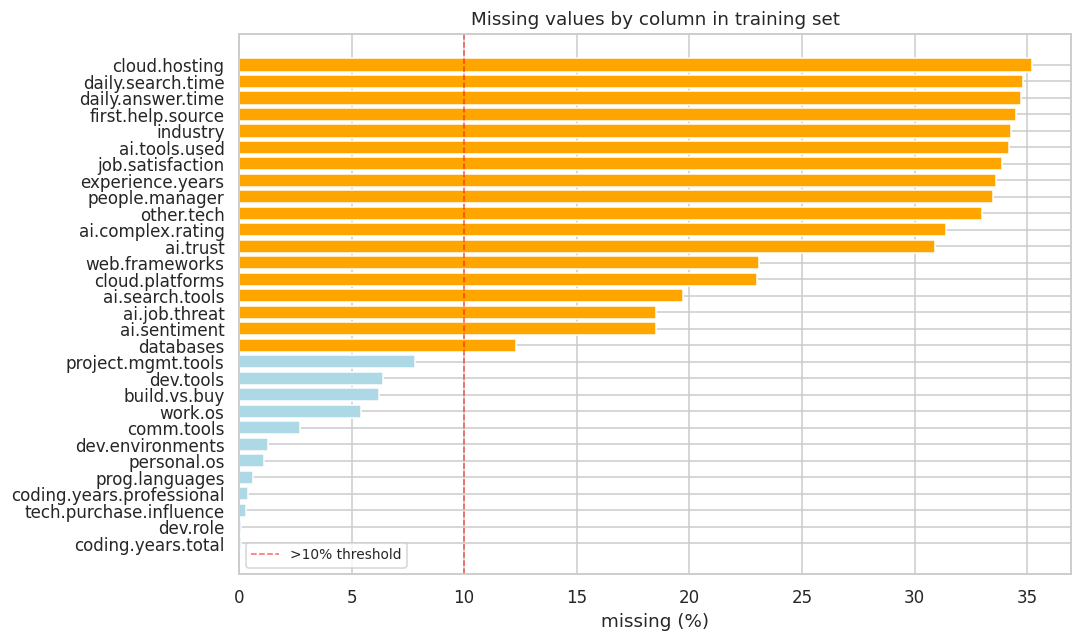

columns with >10% missing: 18
columns with >0% and <=10% missing: 12


columns with no missing: 11
total columns: 41


In [24]:
miss_plot_df = miss_df_train[miss_df_train["n_missing"] > 0].copy()

fig, ax = plt.subplots(figsize=(10, 6))

colors = [
    "orange" if p > MISS_THRESHOLD else "lightblue"
    for p in miss_plot_df["pct_missing"]
]

ax.barh(
    miss_plot_df.index,
    miss_plot_df["pct_missing"],
    color=colors,
    edgecolor="white"
)

ax.axvline(
    MISS_THRESHOLD,
    color="red",
    linestyle="--",
    linewidth=1,
    alpha=0.6,
    label=f">{MISS_THRESHOLD:.0f}% threshold"
)

ax.set_xlabel("missing (%)")
ax.set_title("Missing values by column in training set")
ax.invert_yaxis()
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"columns with >{MISS_THRESHOLD:.0f}% missing: {(miss_df_train['pct_missing'] > MISS_THRESHOLD).sum()}")
print(f"columns with >0% and <={MISS_THRESHOLD:.0f}% missing: {((miss_df_train['pct_missing'] > 0) & (miss_df_train['pct_missing'] <= MISS_THRESHOLD)).sum()}")
print(f"columns with no missing: {(train_df.isnull().sum() == 0).sum()}")
print(f"total columns: {train_df.shape[1]}")

### Feature engineering function

This function applies all feature engineering transformations to the training, validation, and test sets in the same way. Whenever a transformation depends on the data distribution, such as selecting the most common technology items, the rule is learned only from the training set through `train_ref`. This prevents information leakage from the validation or test data.

The function first standardizes repeated "Other" category variants, then creates missingness indicators for columns with more than 10% missing values in the training set. This is important because missing values may contain useful information, especially for AI-related survey questions.

Next, the function improves the experience variables. Since `coding.years.total` and `coding.years.professional` are strongly related, the total column is replaced with `years.before.professional`, which captures how many years someone coded before becoming a professional developer. Additional squared and log-transformed experience features are added to capture nonlinear salary effects and diminishing returns.

Ordered categorical variables, such as age group, education, company size, AI sentiment, and AI trust, are converted into numeric values using predefined mappings. The function also extracts seniority-related keywords from `dev.role`, creating binary flags such as `role_is_senior`, `role_is_manager`, and `role_is_principal`.

A region-by-company-size interaction is added to capture the possibility that company size affects salaries differently across regions.

Finally, multi-select columns are transformed into count features and binary indicators for the most common items in the training set. Several `top_n_tech` values (5, 10, 15, 20, 25, 30) were compared using the final SVR-RBF + ElasticNet ensemble structure. `top_n_tech = 25` was retained in v7: it gave the best held-out leaderboard generalisation among the tested values, while keeping the feature matrix smaller than the 30-item variant. The total number of selected technologies and tools is also summarised in `tech_breadth_total`.


In [25]:
def _safe_name(s):
    return re.sub(r"[^a-zA-Z0-9_]", "", s.replace("++", "_plus").replace("#", "_sharp").replace(" ", "_"))


def apply_feature_engineering(df, train_ref, top_n_tech=25):
    """Apply all feature engineering. Data-distribution-dependent rules
    (top-N tech items) are fit on train_ref only to prevent leakage."""
    out = df.copy()

    for col in ["industry", "first.help.source", "dev.role"]:
        if col in out.columns:
            out[col] = out[col].replace({"Other:": "Other", "Other (please specify):": "Other"})

    out["missing_count_total"] = out.isnull().sum(axis=1)
    for col in HIGH_MISS_COLS:
        if col in out.columns:
            out[f"miss_{col}"] = out[col].isna().astype(int)

    if "coding.years.total" in out.columns and "coding.years.professional" in out.columns:
        out["years.before.professional"] = (
            out["coding.years.total"] - out["coding.years.professional"]
        ).clip(lower=0)
        out.drop(columns=["coding.years.total"], inplace=True)

    for col in ["coding.years.professional", "experience.years"]:
        if col in out.columns:
            out[f"{col}_sq"] = out[col] ** 2
            out[f"{col}_log1p"] = np.log1p(out[col].clip(lower=0))

    for col, mp in ORDINAL_MAPS.items():
        if col in out.columns:
            out[col] = out[col].map(mp)

    if "dev.role" in out.columns:
        role_str = out["dev.role"].fillna("").astype(str)
        for kw in ROLE_KEYWORDS:
            out[f"role_is_{kw.lower()}"] = role_str.str.contains(kw, case=False, regex=False).astype(int)

    if "region" in out.columns and "company.size" in out.columns:
        out["region_x_compsize"] = out["region"].astype(str) + "_" + out["company.size"].astype(str)

    total_breadth = pd.Series(0, index=out.index)
    for col in MULTI_SELECT_COLS:
        if col not in out.columns:
            continue

        out[f"{col}_count"] = (
            out[col].fillna("").apply(lambda x: len([i for i in str(x).split(";") if i.strip()]))
        )
        total_breadth += out[f"{col}_count"]

        items = []
        for v in train_ref[col].dropna():
            items.extend(i.strip() for i in str(v).split(";") if i.strip())
        top_items = [it for it, _ in Counter(items).most_common(top_n_tech)]

        for it in top_items:
            new_col = f"{col}_{_safe_name(it)}"
            out[new_col] = out[col].fillna("").apply(
                lambda x: int(it in {i.strip() for i in str(x).split(";")})
            )
        out.drop(columns=[col], inplace=True)

    out["tech_breadth_total"] = total_breadth

    return out


In [26]:
X_train = apply_feature_engineering(train_df, train_ref=train_df, top_n_tech=25)
X_val   = apply_feature_engineering(val_df,   train_ref=train_df, top_n_tech=25)
X_test  = apply_feature_engineering(test_df,  train_ref=train_df, top_n_tech=25)

print(f"X_train: {X_train.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}")


X_train: (1709, 369), X_val: (377, 369), X_test: (377, 369)


In [27]:
created_cols = sorted(set(X_train.columns) - set(train_df.columns))
removed_cols = sorted(set(train_df.columns) - set(X_train.columns))

feature_groups = {
    "Missingness indicators": [c for c in created_cols if c.startswith("miss_")],
    "Count features": [c for c in created_cols if c.endswith("_count")],
    "Seniority role flags": [c for c in created_cols if c.startswith("role_is_")],
    "Squared features": [c for c in created_cols if c.endswith("_sq")],
    "Log features": [c for c in created_cols if c.endswith("_log1p")],
    "Interaction features": [c for c in created_cols if c == "region_x_compsize"],
    "Total breadth feature": [c for c in created_cols if c == "tech_breadth_total"],
    "Experience derived features": [c for c in created_cols if c == "years.before.professional"],
}

already_grouped = set(sum(feature_groups.values(), []))
feature_groups["Top-N multi-select binary indicators"] = [
    c for c in created_cols if c not in already_grouped
]

print("Feature engineering summary")
print(f"Original columns: {train_df.shape[1]}")
print(f"Final columns: {X_train.shape[1]}")
print(f"Created columns: {len(created_cols)}")
print(f"Removed columns: {len(removed_cols)}")

for group_name, cols in feature_groups.items():
    print(f"{group_name}: {len(cols)}")
    for col in cols:
        print(f" - {col}")

print(f"Removed original columns: {len(removed_cols)}")
for col in removed_cols:
    print(f" - {col}")

Feature engineering summary
Original columns: 41
Final columns: 369
Created columns: 344
Removed columns: 16
Missingness indicators: 18
 - miss_ai.complex.rating
 - miss_ai.job.threat
 - miss_ai.search.tools
 - miss_ai.sentiment
 - miss_ai.tools.used
 - miss_ai.trust
 - miss_cloud.hosting
 - miss_cloud.platforms
 - miss_daily.answer.time
 - miss_daily.search.time
 - miss_databases
 - miss_experience.years
 - miss_first.help.source
 - miss_industry
 - miss_job.satisfaction
 - miss_other.tech
 - miss_people.manager
 - miss_web.frameworks
Count features: 15
 - ai.search.tools_count
 - ai.tools.used_count
 - cloud.platforms_count
 - comm.tools_count
 - databases_count
 - dev.environments_count
 - dev.tools_count
 - how.learned.coding_count
 - other.tech_count
 - personal.os_count
 - prog.languages_count
 - project.mgmt.tools_count
 - side.coding_count
 - web.frameworks_count
 - work.os_count
Seniority role flags: 10
 - role_is_architect
 - role_is_director
 - role_is_executive
 - role_is_j

## Preprocessing pipeline

After feature engineering, the columns were divided into separate preprocessing groups so that each type of variable was transformed appropriately before modelling.

- **Target encoding** was applied to high-cardinality categorical variables: `region`, `dev.role`, `industry`, and `region_x_compsize`. These variables may contain strong salary-related information, but one-hot encoding them would create many sparse dummy columns. Target encoding replaces each category with a salary-related numerical value learned from the training set. To reduce overfitting for rare categories, `TargetEncoder` was used with automatic smoothing.

- **One-hot encoding** was applied to lower-cardinality categorical variables such as `employment.type`, `work.location`, `cloud.hosting`, `build.vs.buy`, `first.help.source`, and `ai.job.threat`. These variables have fewer levels, so dummy encoding is still manageable and does not excessively increase dimensionality.

- **Robust scaling** was used for skewed experience-related numerical variables. These features, especially squared experience terms, can still contain outliers even after log transformation. Robust scaling uses the median and interquartile range, making it less sensitive to extreme values.

- **Standard scaling** was applied to the remaining numerical features, including binary flags, ordinal encodings, count features, missingness indicators, and technology indicators. This ensures that continuous and engineered numerical variables are on a comparable scale, which is especially important for SVR and regularized linear models.

In [28]:
EXCLUDE_COLS = ["id", "annual.pay.usd"]

TARGET_ENC_COLS = ["region", "dev.role", "industry", "region_x_compsize"]
TARGET_ENC_COLS = [c for c in TARGET_ENC_COLS if c in X_train.columns]

OHE_COLS = ["employment.type", "work.location", "cloud.hosting", "build.vs.buy", "first.help.source", "ai.job.threat"]
OHE_COLS = [c for c in OHE_COLS if c in X_train.columns]

# robust scaling for experience-related features (still outlier-prone after log)
SKEWED_NUMS = ["coding.years.professional", "experience.years", "years.before.professional", "coding.years.professional_sq", "experience.years_sq", "coding.years.professional_log1p", "experience.years_log1p"]
SKEWED_NUMS = [c for c in SKEWED_NUMS if c in X_train.columns]

NUM_COLS = [
    c for c in X_train.columns
    if c not in EXCLUDE_COLS + TARGET_ENC_COLS + OHE_COLS + SKEWED_NUMS
]

print(f"target-encoded: {len(TARGET_ENC_COLS)} cols -> {TARGET_ENC_COLS}")
print(f"one-hot encoded: {len(OHE_COLS)} cols -> {OHE_COLS}")
print(f"robust-scaled: {len(SKEWED_NUMS)} cols")
print(f"standard-scaled: {len(NUM_COLS)} cols")
print(f"total: {len(TARGET_ENC_COLS) + len(OHE_COLS) + len(SKEWED_NUMS) + len(NUM_COLS)} cols")

target-encoded: 4 cols -> ['region', 'dev.role', 'industry', 'region_x_compsize']
one-hot encoded: 6 cols -> ['employment.type', 'work.location', 'cloud.hosting', 'build.vs.buy', 'first.help.source', 'ai.job.threat']
robust-scaled: 7 cols
standard-scaled: 351 cols
total: 368 cols


The preprocessing stage was implemented as a `ColumnTransformer`, which applies different transformations to different feature groups. Missing categorical values are treated as a separate `"Missing"` category, while missing numerical values are replaced with the training-set median. High-cardinality categorical variables are target-encoded, low-cardinality categorical variables are one-hot encoded, skewed experience-related numerical variables are robust-scaled, and all remaining numerical variables are standard-scaled.

In [29]:
target_enc_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("encoder", TargetEncoder(smooth="auto", target_type="continuous", random_state=SEED)),
])

ohe_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

skew_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler()),
])

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("te", target_enc_pipe, TARGET_ENC_COLS),
        ("ohe", ohe_pipe, OHE_COLS),
        ("skew", skew_pipe, SKEWED_NUMS),
        ("num", num_pipe, NUM_COLS),
    ],
    remainder="drop",
)

## Baseline model comparison

To compare several algorithms, 5-fold cross-validation was performed on the training set. Each model was wrapped in the same preprocessing pipeline, so imputation, encoding, and scaling were fitted only within the training folds and then applied to the validation fold. This prevents information leakage during cross-validation.

Because the models were trained on the log-transformed target, predictions were converted back to dollar values before calculating RMSE.

In [30]:
from sklearn.metrics import make_scorer
from sklearn.model_selection import cross_val_score

kf = KFold(n_splits=5, shuffle=True, random_state=SEED)


def rmse_dollars_from_log(y_log_true, y_log_pred):
    """RMSE on the raw dollar scale, computed from log-space predictions."""
    y_dollars_true = np.expm1(y_log_true)
    y_dollars_pred = np.expm1(y_log_pred)
    return float(np.sqrt(mean_squared_error(y_dollars_true, y_dollars_pred)))


rmse_dollars_scorer = make_scorer(rmse_dollars_from_log, greater_is_better=False)


candidate_models = {
    "Ridge (CV)": RidgeCV(alphas=[0.1, 1.0, 5.0, 10.0, 50.0, 100.0]),
    "LASSO (CV)": LassoCV(cv=5, random_state=SEED, max_iter=20000),
    "ElasticNet (CV)": ElasticNetCV(
        cv=5,
        random_state=SEED,
        max_iter=20000,
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],
        alphas=[0.001, 0.003, 0.01, 0.03, 0.1, 0.3],
    ),
    "KNN (k=30)": KNeighborsRegressor(n_neighbors=30, weights="distance"),
    "SVR-RBF baseline": SVR(kernel="rbf", C=1.0, epsilon=0.1, gamma="scale"),
}


baseline_results = {}

print(f"{'Model':<22} {'CV-RMSE ($)':>14}")
print("-" * 38)

for name, mdl in candidate_models.items():
    pipe = Pipeline([("pre", preprocessor), ("model", mdl)])
    scores = cross_val_score(
        pipe, X_train, y_train,
        cv=kf, scoring=rmse_dollars_scorer, n_jobs=-1,
    )
    cv_rmse = -scores.mean()
    baseline_results[name] = cv_rmse
    print(f"{name:<22} ${cv_rmse:>12,.0f}")


Model                     CV-RMSE ($)
--------------------------------------


Ridge (CV)             $     100,184


LASSO (CV)             $      94,513


ElasticNet (CV)        $      94,854


KNN (k=30)             $      98,554


SVR-RBF baseline       $      92,150


## SVR hyperparameter search

The baseline comparison showed that SVR-RBF was the strongest individual candidate model among the tested algorithms. It achieved the lowest 5-fold cross-validation RMSE in dollars, outperforming Ridge, LASSO, ElasticNet and KNN. Because of this, SVR-RBF was tuned more carefully using grid search.

In [31]:
# Wider grid than v5: extended DOWNWARD on C and gamma so the optimum can land
# in the interior. v5's grid bottomed out at C=1.0 / gamma="scale", which is
# a symptom of the model wanting more flexibility, not less - extending
# downward (toward more smoothing) would not have helped, because the data
# is no longer being winsorised at the top tail in v7.
svr_pipeline = Pipeline([
    ("pre", preprocessor),
    ("svr", SVR(kernel="rbf")),
])

svr_grid = {
    "svr__C":       [0.3, 1.0, 3.0, 10.0, 30.0],
    "svr__epsilon": [0.05, 0.1, 0.2],
    "svr__gamma":   ["scale", 0.001, 0.005, 0.02],
}

n_configs = len(svr_grid["svr__C"]) * len(svr_grid["svr__epsilon"]) * len(svr_grid["svr__gamma"])
print(f"searching {n_configs} SVR configurations x 5 folds = {n_configs * 5} fits")

svr_search = GridSearchCV(
    svr_pipeline,
    param_grid=svr_grid,
    cv=kf,
    scoring=rmse_dollars_scorer,
    n_jobs=-1,
    verbose=0,
)
svr_search.fit(X_train, y_train)

print(f"best SVR params: {svr_search.best_params_}")
print(f"best CV RMSE from grid search: ${-svr_search.best_score_:,.0f}")

for param, grid_vals in svr_grid.items():
    best = svr_search.best_params_[param]
    if best == grid_vals[0]:
        print(f"  NOTE: {param}={best} is at the LOW end of the grid")
    elif best == grid_vals[-1]:
        print(f"  NOTE: {param}={best} is at the HIGH end of the grid - consider extending upward")

svr_best_pipe = svr_search.best_estimator_
val_svr_log = svr_best_pipe.predict(X_val)
svr_val_rmse = rmse_dollars_from_log(y_val, val_svr_log)
print(f"SVR validation RMSE: ${svr_val_rmse:,.0f}")


searching 60 SVR configurations x 5 folds = 300 fits


best SVR params: {'svr__C': 1.0, 'svr__epsilon': 0.05, 'svr__gamma': 0.001}
best CV RMSE from grid search: $91,937
  NOTE: svr__epsilon=0.05 is at the LOW end of the grid
SVR validation RMSE: $33,515


## ElasticNet hyperparameter search

LASSO was slightly better than ElasticNet in the baseline comparison, but the difference was very small. ElasticNet was still tuned further because the dataset contains many correlated engineered indicators, especially from multi-select technology features.

In [32]:
en_pipeline = Pipeline([
    ("pre", preprocessor),
    ("en", ElasticNet(random_state=SEED, max_iter=30000)),
])

en_grid = {
    "en__alpha":    [0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1.0],
    "en__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9],
}

print(f"searching {7 * 5} ElasticNet configurations x 5 folds = {7 * 5 * 5} fits")

en_search = GridSearchCV(
    en_pipeline,
    param_grid=en_grid,
    cv=kf,
    scoring=rmse_dollars_scorer,
    n_jobs=-1,
    verbose=0,
)
en_search.fit(X_train, y_train)

print(f"best ElasticNet params: {en_search.best_params_}")
print(f"best CV RMSE from grid search: ${-en_search.best_score_:,.0f}")

en_best_pipe = en_search.best_estimator_
val_en_log = en_best_pipe.predict(X_val)
en_val_rmse = rmse_dollars_from_log(y_val, val_en_log)
print(f"ElasticNet validation RMSE: ${en_val_rmse:,.0f}")


searching 35 ElasticNet configurations x 5 folds = 175 fits


best ElasticNet params: {'en__alpha': 0.03, 'en__l1_ratio': 0.9}
best CV RMSE from grid search: $93,744
ElasticNet validation RMSE: $35,492


## Validation set evaluation and linear ensemble

After hyperparameter tuning we use the held-out validation split (never touched during model selection) to make two final decisions per model — whether to apply Duan's smearing correction on back-transform, and how to weight the SVR + ElasticNet linear ensemble. The internal test set is then looked at exactly once as an out-of-sample sanity check.


Validation RMSE on raw $ scale:
  SVR naive   $      33,523   smear $      33,470  (factor 1.0350)
  EN  naive   $      35,496   smear $      34,649  (factor 1.5440)

Decision - smearing SVR: True
Decision - smearing EN : True

Ensemble weight scan (SVR=0.60, EN=0.40)
  Best ensemble val-RMSE: $32,452
  SVR alone val-RMSE   : $33,470
  EN  alone val-RMSE   : $34,649


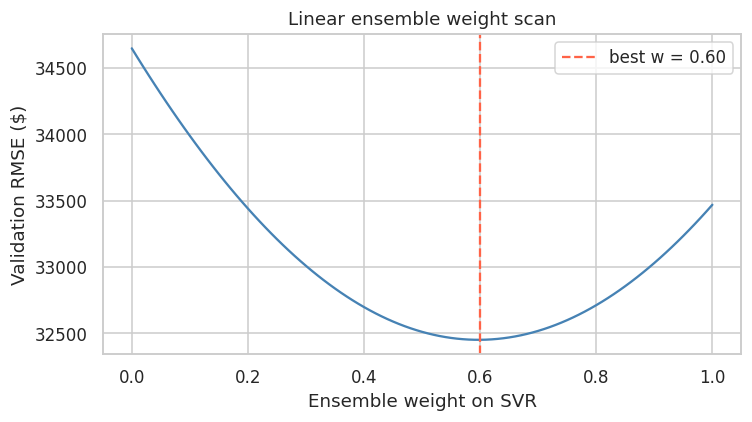

In [33]:
# Refit on TRAIN only; use the held-out validation split (never touched during
# model selection) to:
#   (a) decide whether Duan's smearing improves dollar-scale RMSE per model,
#   (b) learn the linear ensemble weight.
svr_fit = clone(svr_best_pipe).fit(X_train, y_train)
en_fit  = clone(en_best_pipe).fit(X_train, y_train)

val_log_svr = svr_fit.predict(X_val)
val_log_en  = en_fit.predict(X_val)

val_usd_svr_naive = np.expm1(val_log_svr)
val_usd_en_naive  = np.expm1(val_log_en)

# Duan's smearing factor from TRAINING residuals (no leakage from val/test)
train_log_pred_svr = svr_fit.predict(X_train)
train_log_pred_en  = en_fit.predict(X_train)
smear_svr = float(np.mean(np.exp(y_train - train_log_pred_svr)))
smear_en  = float(np.mean(np.exp(y_train - train_log_pred_en)))

val_usd_svr_smear = np.expm1(val_log_svr + np.log(smear_svr))
val_usd_en_smear  = np.expm1(val_log_en  + np.log(smear_en))

val_dollars = val_df[TARGET].values


def rmse(a, b):
    return float(np.sqrt(mean_squared_error(a, b)))


# Adopt smearing only if it improves validation dollar-scale RMSE.
use_smear_svr = rmse(val_dollars, val_usd_svr_smear) < rmse(val_dollars, val_usd_svr_naive)
use_smear_en  = rmse(val_dollars, val_usd_en_smear)  < rmse(val_dollars, val_usd_en_naive)

val_usd_svr = val_usd_svr_smear if use_smear_svr else val_usd_svr_naive
val_usd_en  = val_usd_en_smear  if use_smear_en  else val_usd_en_naive

# Linear ensemble weight from a 1-D scan on validation.
ws = np.linspace(0.0, 1.0, 101)
rmses = [rmse(val_dollars, w * val_usd_svr + (1 - w) * val_usd_en) for w in ws]
best_w = float(ws[int(np.argmin(rmses))])
best_rmse = float(np.min(rmses))

print("Validation RMSE on raw $ scale:")
print(f"  SVR naive   ${rmse(val_dollars, val_usd_svr_naive):>12,.0f}   smear ${rmse(val_dollars, val_usd_svr_smear):>12,.0f}  (factor {smear_svr:.4f})")
print(f"  EN  naive   ${rmse(val_dollars, val_usd_en_naive):>12,.0f}   smear ${rmse(val_dollars, val_usd_en_smear):>12,.0f}  (factor {smear_en:.4f})")
print(f"\nDecision - smearing SVR: {use_smear_svr}")
print(f"Decision - smearing EN : {use_smear_en}")
print(f"\nEnsemble weight scan (SVR={best_w:.2f}, EN={1-best_w:.2f})")
print(f"  Best ensemble val-RMSE: ${best_rmse:,.0f}")
print(f"  SVR alone val-RMSE   : ${rmse(val_dollars, val_usd_svr):,.0f}")
print(f"  EN  alone val-RMSE   : ${rmse(val_dollars, val_usd_en):,.0f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ws, rmses, color="steelblue")
ax.axvline(best_w, color="tomato", ls="--", label=f"best w = {best_w:.2f}")
ax.set_xlabel("Ensemble weight on SVR")
ax.set_ylabel("Validation RMSE ($)")
ax.set_title("Linear ensemble weight scan")
ax.legend()
plt.tight_layout()
plt.show()


## Validation set evaluation

After hyperparameter tuning, both models were refitted on the training set and evaluated on the separate validation set. Since the models were trained on the log-transformed target, predictions were converted back to dollars before calculating RMSE.

Two back-transformation strategies were compared: a naive inverse transformation using `expm1()` and Duan's smearing correction. The smearing factor was calculated only from training residuals, which avoids leakage from the validation or test sets. The validation set was then used to decide whether the smearing-adjusted prediction improved RMSE for each model.

This step helps correct possible downward bias caused by transforming log predictions back to the original dollar scale. The final internal test evaluation is kept separate and used as an additional out-of-sample check after these validation-based decisions.

### Linear ensemble

The final prediction is a weighted average of the SVR-RBF and ElasticNet predictions:

`ensemble = w × SVR + (1 − w) × ElasticNet`

The weight `w` was selected on the validation set by scanning values from 0 to 1 and choosing the one with the lowest validation RMSE. This allows the final model to combine the nonlinear flexibility of SVR with the more stable linear structure of ElasticNet.

## Internal test set evaluation

We look at the internal test set exactly once, using models fitted on training only, smearing factors from training residuals, and the ensemble weight from validation.

In [34]:
test_log_svr = svr_fit.predict(X_test)
test_log_en = en_fit.predict(X_test)

test_usd_svr = (
    np.expm1(test_log_svr + np.log(smear_svr)) if use_smear_svr else np.expm1(test_log_svr)
)
test_usd_en = (
    np.expm1(test_log_en + np.log(smear_en)) if use_smear_en else np.expm1(test_log_en)
)
test_usd_ens = best_w * test_usd_svr + (1 - best_w) * test_usd_en

test_dollars = test_df[TARGET].values

print("Internal test RMSE:")
print(f" SVR alone: ${rmse(test_dollars, test_usd_svr):,.0f}")
print(f" ElasticNet: ${rmse(test_dollars, test_usd_en):,.0f}")
print(f" Ensemble: ${rmse(test_dollars, test_usd_ens):,.0f}")

Internal test RMSE:
 SVR alone: $72,953
 ElasticNet: $73,441
 Ensemble: $72,799


In [35]:
test_abs_err = np.abs(test_dollars - test_usd_ens)
order = np.argsort(test_abs_err)[::-1]

print("Internal test RMSE, removing largest-error rows one at a time:")
for k in [0, 1, 2, 3, 5, 10]:
    keep = order[k:]
    rmse_k = float(np.sqrt(mean_squared_error(test_dollars[keep], test_usd_ens[keep])))
    print(f"  exclude top {k:>2}: ${rmse_k:,.0f}  ({len(keep)} rows)")

print("\nTop 5 test errors (likely currency-contaminated):")
for i in order[:5]:
    print(f"  true=${test_dollars[i]:>12,.0f}  pred=${test_usd_ens[i]:>10,.0f}  region={test_df['region'].iloc[i]}")

Internal test RMSE, removing largest-error rows one at a time:
  exclude top  0: $72,799  (377 rows)
  exclude top  1: $35,148  (376 rows)
  exclude top  2: $33,322  (375 rows)
  exclude top  3: $31,556  (374 rows)
  exclude top  5: $29,491  (372 rows)
  exclude top 10: $27,526  (367 rows)

Top 5 test errors (likely currency-contaminated):
  true=$   1,265,213  pred=$    26,868  region=R17
  true=$     299,090  pred=$    79,736  region=R11
  true=$     281,443  pred=$    71,758  region=R13
  true=$     190,756  pred=$    26,675  region=R17
  true=$     178,158  pred=$    29,995  region=R17


## Final refit and submission

After selecting the final configuration, both models were refitted on all labelled observations, combining the original training, validation and internal test splits. This gives the final models as much labelled data as possible before generating Kaggle predictions.

The hyperparameters, smearing decisions and ensemble weight were kept fixed based on the earlier validation procedure. Since the final models were refitted on the full labelled dataset, the smearing factors were recalculated using residuals from this full labelled sample.

In [36]:
# Refit on ALL labelled rows. We deliberately do NOT call
# clean_training_targets here - the upper-tail capping was removed in v7
# (and never existed in v6), so the only "cleaning" is the R17 low-tail drop
# which we re-apply for consistency with the modelling distribution.
full_df_raw = pd.concat([train_df, val_df, test_df], ignore_index=True)
y_full = make_log_target(full_df_raw).values

X_full_fe   = apply_feature_engineering(full_df_raw, train_ref=train_df, top_n_tech=25)
X_kaggle_fe = apply_feature_engineering(kaggle_raw,  train_ref=train_df, top_n_tech=25)

svr_final = Pipeline([
    ("pre", preprocessor),
    ("svr", SVR(kernel="rbf",
                C=svr_search.best_params_["svr__C"],
                epsilon=svr_search.best_params_["svr__epsilon"],
                gamma=svr_search.best_params_["svr__gamma"])),
]).fit(X_full_fe, y_full)

en_final = Pipeline([
    ("pre", preprocessor),
    ("en", ElasticNet(random_state=SEED, max_iter=30000,
                      alpha=en_search.best_params_["en__alpha"],
                      l1_ratio=en_search.best_params_["en__l1_ratio"])),
]).fit(X_full_fe, y_full)

# Recompute smearing factors against the model now fitted on FULL data
# (the smearing *decision* use_smear_* is kept from the validation evaluation).
train_log_pred_svr_full = svr_final.predict(X_full_fe)
train_log_pred_en_full  = en_final.predict(X_full_fe)
smear_svr_full = float(np.mean(np.exp(y_full - train_log_pred_svr_full)))
smear_en_full  = float(np.mean(np.exp(y_full - train_log_pred_en_full)))

k_log_svr = svr_final.predict(X_kaggle_fe)
k_log_en  = en_final.predict(X_kaggle_fe)

k_usd_svr = (
    np.expm1(k_log_svr + np.log(smear_svr_full)) if use_smear_svr else np.expm1(k_log_svr)
)
k_usd_en = (
    np.expm1(k_log_en + np.log(smear_en_full)) if use_smear_en else np.expm1(k_log_en)
)

k_usd_final = best_w * k_usd_svr + (1 - best_w) * k_usd_en
k_usd_final = np.clip(k_usd_final, MIN_SALARY_FLOOR, None)

submission = pd.DataFrame({
    "id":             kaggle_raw[ID_COL].values,
    "annual.pay.usd": k_usd_final,
})

out_name = "submission_NA_final_v7.csv"
submission.to_csv(out_name, index=False)
print(f"saved: {out_name}")
print(submission["annual.pay.usd"].describe().round(0))
for q in [0.01, 0.05, 0.5, 0.95, 0.99]:
    print(f" P{int(q*100):>2d}: ${submission['annual.pay.usd'].quantile(q):>10,.0f}")


saved: submission_NA_final_v7.csv
count       628.0
mean      48116.0
std       25860.0
min        7555.0
25%       28153.0
50%       43168.0
75%       62406.0
max      153102.0
Name: annual.pay.usd, dtype: float64
 P 1: $    10,138
 P 5: $    14,810
 P50: $    43,168
 P95: $    93,280
 P99: $   127,831


## Summary

In [37]:
print(f"final model: SVR-RBF (weight {best_w:.2f}) + ElasticNet (weight {1-best_w:.2f})")
print(f"SVR params: {svr_search.best_params_}")
print(f"ElasticNet params: {en_search.best_params_}")
print(f"feature matrix: {X_full_fe.shape[1]} columns")
print(f"smearing - SVR: {use_smear_svr} (factor {smear_svr_full:.4f})")
print(f"smearing - EN : {use_smear_en} (factor {smear_en_full:.4f})")
print(f"val RMSE (held-out ensemble): ${best_rmse:,.0f}")
print(f"internal test RMSE:           ${rmse(test_dollars, test_usd_ens):,.0f}")


final model: SVR-RBF (weight 0.60) + ElasticNet (weight 0.40)
SVR params: {'svr__C': 1.0, 'svr__epsilon': 0.05, 'svr__gamma': 0.001}
ElasticNet params: {'en__alpha': 0.03, 'en__l1_ratio': 0.9}
feature matrix: 369 columns
smearing - SVR: True (factor 1.0390)
smearing - EN : True (factor 1.6360)
val RMSE (held-out ensemble): $32,452
internal test RMSE:           $72,799
